In [1]:
import numpy as np
import re
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, PauliError
from qiskit.quantum_info import Statevector, Pauli, SparsePauliOp, StabilizerState, DensityMatrix
from scipy.optimize import minimize

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

from xgboost import XGBRegressor

import pandas as pd
import tqdm as tqdm

import matplotlib.pyplot as plt

num_qubits = 12
num_layers = 4

ansatz = TwoLocal(
    num_qubits,
    rotation_blocks='ry',
    entanglement_blocks='cx',
    entanglement='circular',
    reps=num_layers,
    skip_final_rotation_layer=True,
    insert_barriers=True
)

observables = []
for i in range(num_qubits):
    for j in range(i+1, num_qubits):
        pauli_str = ['I'] * num_qubits
        pauli_str[i] = 'Z'
        pauli_str[j] = 'Z'
        observables.append(Pauli(''.join(pauli_str)))
        
for i in range(num_qubits):
    pauli_str = ['I'] * num_qubits
    pauli_str[i] = 'X'
    observables.append(Pauli(''.join(pauli_str)))

backend_noiseless = AerSimulator(method='statevector')

df = pd.read_csv('./data/sk-hamiltonians.csv')
energies = []

for i in tqdm.tqdm(range(len(df))):
    coefs = df['coefs'][i]
    params = df['params'][i]
    params_clean = re.sub(r'\s+', ' ', params.strip('[]\n '))
    params = np.fromstring(params_clean, sep=' ')

    result = eval(coefs)
    coefs = np.array(result, dtype=float)
    coefs = np.concatenate((coefs, np.array([1.]*num_qubits)))

    bound_circuit = ansatz.assign_parameters(params)

    transpiled = transpile(bound_circuit, backend_noiseless)
    transpiled.save_statevector()
    job = backend_noiseless.run(transpiled)
    result = job.result()
    statevector = result.get_statevector()

    noiseless_e = sum([np.real(statevector.expectation_value(obs)) for obs in observables]*coefs)
    energies.append(noiseless_e)

energies = np.array(energies)

C:\Temp\ipykernel_4428\753549379.py:25: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  8.31it/s]


In [2]:
df_depol = pd.read_csv('./data/error_stats/error_stats_depolarization005.csv')
df_pauli = pd.read_csv('./data/error_stats/error_stats_pauli005.csv')
df_composite = pd.read_csv('./data/error_stats/error_stats_composite005.csv')

zne_depol = pd.read_csv('./data/error_stats/zne_depolarization005.csv')
zne_pauli = pd.read_csv('./data/error_stats/zne_pauli005.csv')
zne_composite = pd.read_csv('./data/error_stats/zne_composite005.csv')

data1 = np.abs(np.array(df_depol['ridge_near'] - energies))
data2 = np.abs(np.array(zne_depol['zne']- energies))
data3 = np.abs(np.array(df_depol['noisy'] - energies))

data4 = np.abs(np.array(df_pauli['ridge_near'] - energies))
data5 = np.abs(np.array(zne_pauli['zne']- energies))
data6 = np.abs(np.array(df_pauli['noisy'] - energies))

data7 = np.abs(np.array(df_composite['xgb_full'] - energies))
data8 = np.abs(np.array(zne_composite['zne']- energies))
data9 = np.abs(np.array(df_composite['noisy'] - energies))

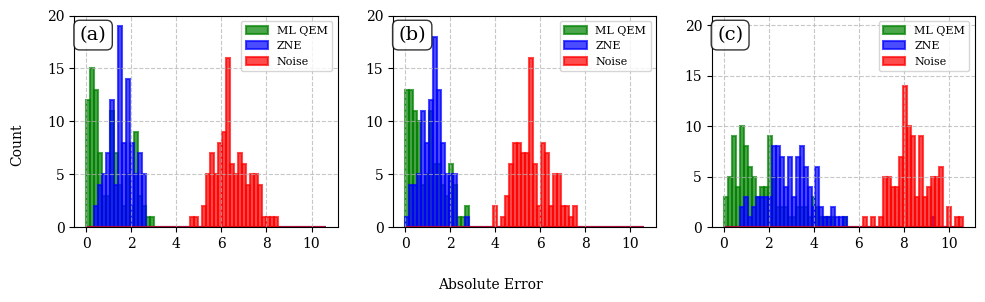

In [3]:
import numpy as np

# ---------- 1. FONT SETUP (LaTeX-like, but no external LaTeX needed) ----------
plt.rcParams.update({
    "font.family": "serif",               # use serif font (like LaTeX)
    "mathtext.fontset": "cm",              # Computer Modern for math
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 8,
    "text.usetex": False                   # do not use external LaTeX
})

# ---------- 2. CREATE 1x3 SUBPLOTS ----------
fig, axes = plt.subplots(1, 3, figsize=(10, 3), facecolor='white')

# ---------- 3. DATA (assumed to be defined elsewhere) ----------
# data1, data2, ..., data9 should exist in the namespace.
# They are grouped as:
#   Group 1: data1, data2, data3  -> Depolarizing
#   Group 2: data4, data5, data6  -> Pauli
#   Group 3: data7, data8, data9  -> Amplitude Damping

# ---------- 4. COMMON BINS FOR ALL SUBPLOTS ----------
all_data = [data1, data2, data3, data4, data5, data6, data7, data8, data9]
global_min = min(np.min(d) for d in all_data)
global_max = max(np.max(d) for d in all_data)
num_bins = 60
common_bins = np.linspace(global_min, global_max, num_bins + 1)

# ---------- 5. PLOT EACH SUBPLOT ----------
titles = [r"Depolarizing", r"Pauli", r"Amplitude damping"]
legend_labels = [r"ML QEM", r"ZNE", r"Noise"]
colors = ['green', 'blue', 'red']
subplot_labels = ['(a)', '(b)', '(c)']

for i, ax in enumerate(axes):
    if i == 0:
        d1, d2, d3 = data1, data2, data3
    elif i == 1:
        d1, d2, d3 = data4, data5, data6
    else:
        d1, d2, d3 = data7, data8, data9

    # Plot histograms
    ax.hist(d1, bins=common_bins, label=legend_labels[0],
            color=colors[0], alpha=0.7, edgecolor=colors[0], linewidth=1.5)
    ax.hist(d2, bins=common_bins, label=legend_labels[1],
            color=colors[1], alpha=0.7, edgecolor=colors[1], linewidth=1.5)
    ax.hist(d3, bins=common_bins, label=legend_labels[2],
            color=colors[2], alpha=0.7, edgecolor=colors[2], linewidth=1.5)

    # Grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    # Legend
    ax.legend()

    # Annotate with (a), (b), (c) in top-left corner (bold, LaTeX style)
    ax.text(0.02, 0.95, subplot_labels[i],
            transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3",
                                               facecolor="white", alpha=0.8))

# ---------- 6. MAKE Y‑SCALE IDENTICAL ACROSS SUBPLOTS ----------
# Collect current y‑limits
y_maxes = [ax.get_ylim()[1] for ax in axes]
global_y_max = max(y_maxes) * 1.05   # add 5% headroom

for ax in axes:
    ax.set_ylim(0, global_y_max)
axes[0].set_ylim(0, 20)
axes[1].set_ylim(0, 20)
# ---------- 7. COMMON LABELS ----------
fig.supxlabel(r'Absolute Error', fontsize=10)
fig.supylabel(r'Count', fontsize=10)

plt.tight_layout()